# Extraction of ego-net from vk.com

## Imports

In [24]:
pip install -Uq pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -Uq numpy pandas networkx matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import requests
import networkx as nx
import time
import json

import numpy as np
import matplotlib.pyplot as plt

## Get secrets

In [4]:
with open("secrets.json") as f:
    secrets = json.load(f)
    my_user_id = secrets["my_user_id"]
    version = secrets["version"]
    my_access_token = secrets["my_access_token"]

## VK API requests

In [ ]:
# inspired by https://habr.com/ru/articles/263313/
def get_friends_ids(user_id, access_token=my_access_token, version=version):
    
    friends_url = (
        'https://api.vk.com/method/friends.get?'
        'user_id={}&'
        'access_token={}&'
        'v={}'
        )

    json_response = requests.get(friends_url.format(user_id, access_token, version)).json()
    
    if json_response.get('error'):
        print(json_response.get('error'))
        return list()
    return json_response[u'response'][u'items']

In [ ]:
graph = {}
friend_ids = get_friends_ids(my_user_id)  # ваш user id, для которого вы хотите построить граф друзей.
for friend_id in friend_ids:
    time.sleep(0.3)
    print('Processing id: ', friend_id)
    graph[friend_id] = get_friends_ids(friend_id)


In [102]:
len(list(node for node, neighbors in graph.items() if len(neighbors) > 0))

123

## Save graph

In [107]:
# drop private profiles
private_profiles = set()

for node, neighbors in graph.items():
    if len(neighbors) == 0:
        private_profiles.add(node)


public_profiles = list(set(friend_ids) - private_profiles)

len(public_profiles)

123

In [124]:
g = nx.Graph(directed=False)
for friend_id in public_profiles:
    g.add_node(friend_id)
    for ffriend_id in graph[friend_id]:
        if friend_id != ffriend_id and ffriend_id in public_profiles:
            g.add_edge(friend_id, ffriend_id)

In [126]:
nx.write_gml(g, 'ego_net.gml')

In [ ]:
(
    nx.convert_matrix.to_pandas_edgelist(g)
    .to_csv("ego_net_edgelist.csv", sep=";", encoding="utf-8", index=False)
)

## Network summary
1. The network is the ego network of my profile in vk.com. Data is collected using api.vk.com. I select only public profiles to analyse here, preventing large numbers of low degree nodes with private profiles.
2. Nodes are my friends' user_ids (obviously excluding me) and edge relation is for 2 users to be friends
3. There are 123 nodes and 371 edges
4. The net is a homogeneous unweighted undirected graph
5. There are no attributes neither for nodes nor for edges
6. The degree distribution scatter plot shows that the net is scale free (heavy tail)
7. The GCC of net satisfies to small-world property. Nevertheless the random graph show supersmall-world
8. The net demonstrates high clustering, around 9 times greater clustering coefficient than in random net
9. It looks to me that there are 4 or 5 strong communities

In [5]:
g = nx.read_gml('ego_net.gml')

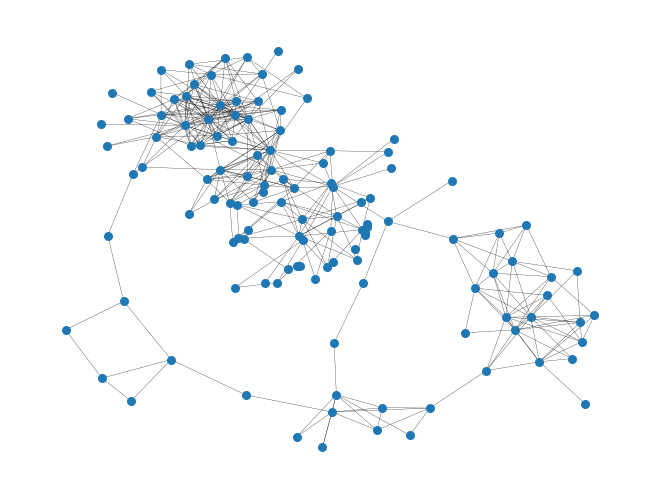

In [6]:
# plot GCC
pos = nx.layout.kamada_kawai_layout(g)
nx.draw(g, pos, node_size=30, with_labels=False, width=0.2)


In [7]:
# numbers of nodes and edges
num_n = len(g.nodes)
num_e = len(g.edges)
num_n, num_e

(123, 371)

In [8]:
# Generate random graph
random_g = nx.gnm_random_graph(123, num_e, seed=37)
print("Random graph #nodes =", len(random_g.nodes), "  #edges =", len(random_g.edges))

Random graph #nodes = 123   #edges = 371


In [9]:
# numbers of isolated nodes
len(list(node for node in g.nodes if nx.degree(g, node) == 0))

11

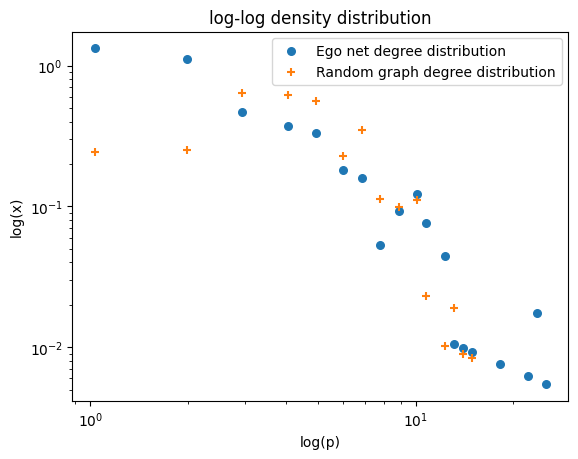

In [10]:
# power law
degrees = list(dict(nx.degree(g)).values())
n_bins = 50

deg_max = np.max(degrees)
x_space = np.geomspace(1, deg_max, n_bins + 1)

hist, bin_edges = np.histogram(degrees, bins=x_space, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], marker="o", s=30, label='Ego net degree distribution')

# random law
random_degrees = list(dict(nx.degree(random_g)).values())

random_hist, _ = np.histogram(random_degrees, bins=x_space, density=True)
plt.scatter(bin_centers[random_hist > 0], random_hist[random_hist > 0], marker="+", s=30, label='Random graph degree distribution')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("log-log density distribution")
plt.xlabel("log(p)")
plt.ylabel("log(x)")
plt.show()


In [ ]:
# Average distance
gcc = nx.subgraph(g, max(nx.connected_components(g), key=len))

l = nx.average_shortest_path_length(gcc)  # noqa: E741
print(l, "~", np.log(len(gcc)))
print(f"|V(GCC)| = {len(gcc)}")

# Random graph distance
random_gcc = nx.subgraph(random_g, max(nx.connected_components(random_g), key=len))

random_l = nx.average_shortest_path_length(random_gcc)  # noqa: E741
print(random_l, "!~", np.log(len(random_gcc)))
print(f"|V(GCC)| = {len(random_gcc)}")


4.430841924398625 ~ 4.574710978503383
|V(GCC)| = 97
2.8431294149007065 !~ 4.812184355372417
|V(GCC)| = 123


In [36]:
# Clustering coefficient
clustering = nx.average_clustering(g)
random_clustering = nx.average_clustering(random_g)
p = num_e * 2 / (num_n * (num_n - 1))

print(f"Clustering coefficient: {clustering:.2f}")
print(f"Random graph clustering coefficient: {random_clustering:.2f} ~ {p:.2f} (probability)")
print(f"My network is ~{clustering / random_clustering:.0f} more clustered than random graph")

Clustering coefficient: 0.47
Random graph clustering coefficient: 0.05 ~ 0.05 (probability)
My network is ~9 more clustered than random graph


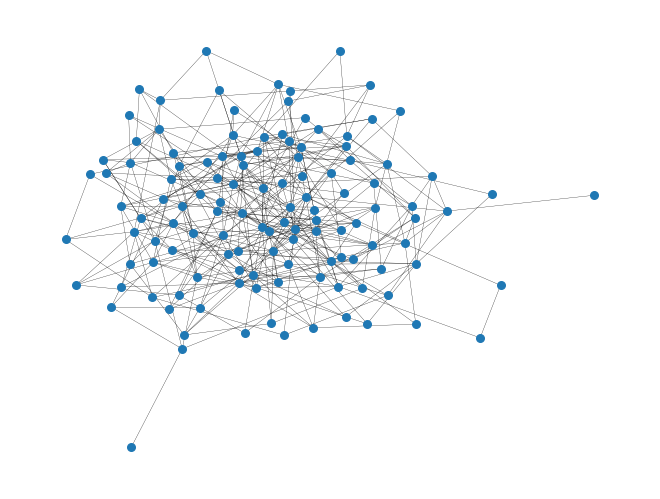

In [12]:
nx.draw(random_gcc, node_size=30, with_labels=False, width=0.2)

## Structural analysis
1. Network models comparison
    - ER (random graph) - my net is not similar to ER model according to clustering, degree distribution or any other structural parameter
    - BA (preferential attachment) - while structural properties look similar, BA model is leaning to make 1 strong community, when my net shows at least 4 obvious communities
    - WS (small-world) -  my net is not similar to WS model according to clustering (my < WS), degree distribution or any other structural parameter
2. Centrality measures
    - Degree centrality top node is id329115238, he is my best friend from the school. It is expected for him to have the most degree in my ego network because we share a lot of life experience and thus a lot of friends
    - Betweenness centrality top node is id171705539, she is my fiance and she added a lot of her friends into my ego net - the community of school friends is weakly connected with the community of fiance's friends
    - The top Closeness centrality node is again my best school friend id329115238
    - Top 5 nodes by Eigenvector centrality measure are counselors at my lovely children's camp

In [48]:
def attach(node, G, m):
    edges = []
    for edge in G.edges:
      edges.extend(edge)

    targets = set()
    while len(targets) < m:
      t = edges[np.random.randint(len(edges))]
      targets.add(t)

    for t in targets:
      G.add_edge(node, t)

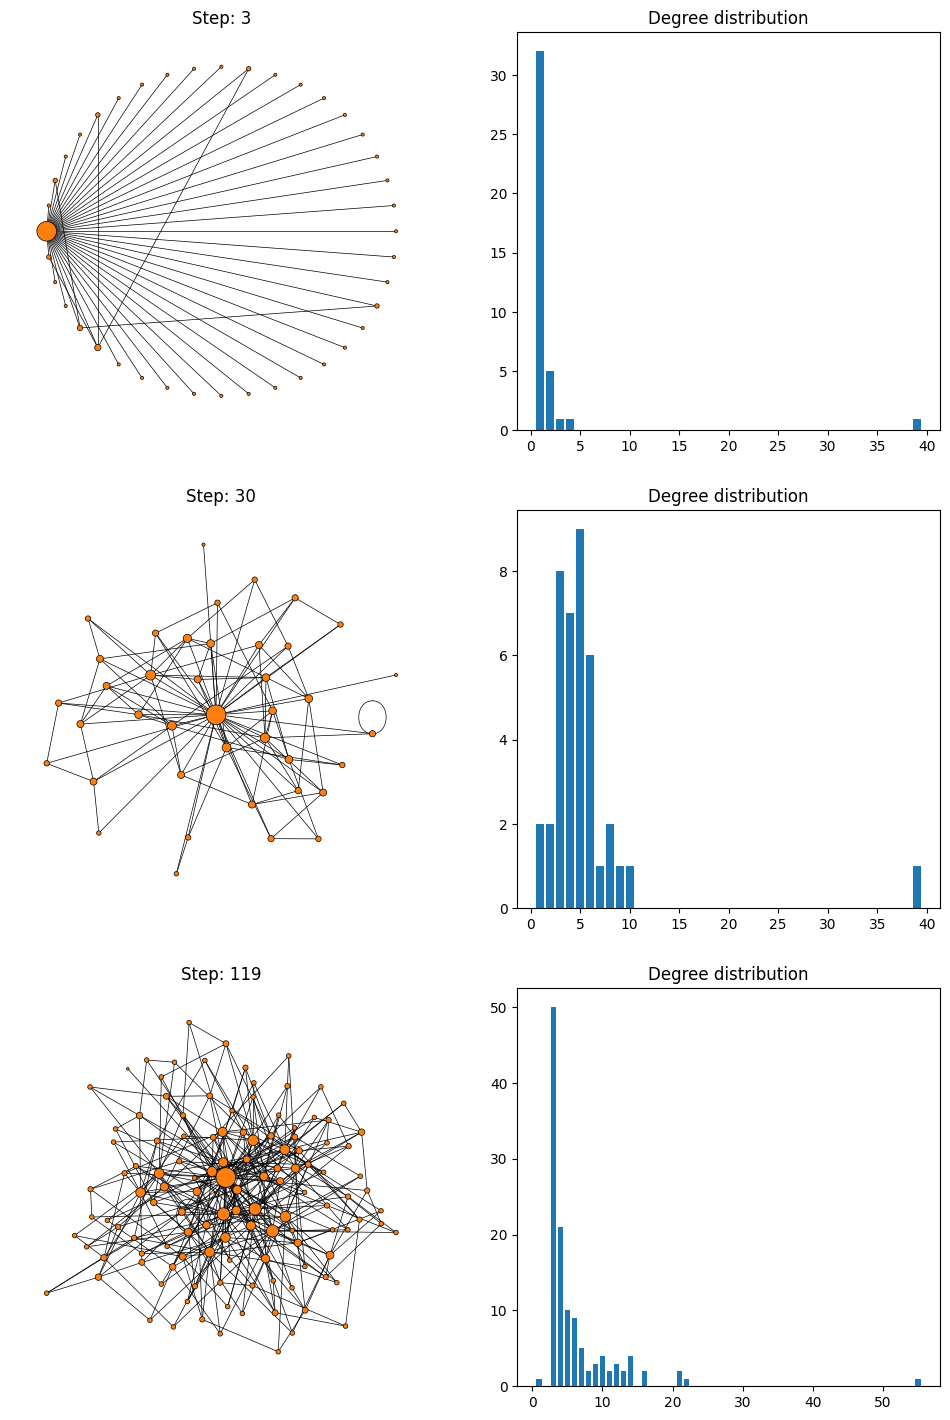

In [50]:
n, m = 123, 3
G = nx.star_graph(39)
plt.figure(figsize=(12, 6 * 5))
j = 1
for i in range(1, n - m):
    if i in [3, 30, n-m-1]:
        plt.subplot(5, 2, j)
        j += 1
        sizes = np.array(list(nx.degree_centrality(G).values()))
        sizes = sizes / max(sizes) * 200
        if i <= 3:
            pos = nx.layout.shell_layout(G)
        else:
            pos = nx.layout.spring_layout(G)
        nx.draw(
            G,
            pos=pos,
            with_labels=False,
            node_size=sizes,
            width=0.5,
            linewidths=0.5,
            edgecolors='black',
            node_color='tab:orange')
        plt.title('Step: {}'.format(i))
        degree_seq = [degree for (node, degree) in G.degree]
        bins, freq = np.unique(degree_seq, return_counts=True)
        plt.subplot(5, 2, j)
        j += 1
        plt.bar(bins, freq)
        plt.title('Degree distribution')
    attach(m + i, G, m)

In [44]:
len(G.nodes), len(G.edges)

(123, 371)

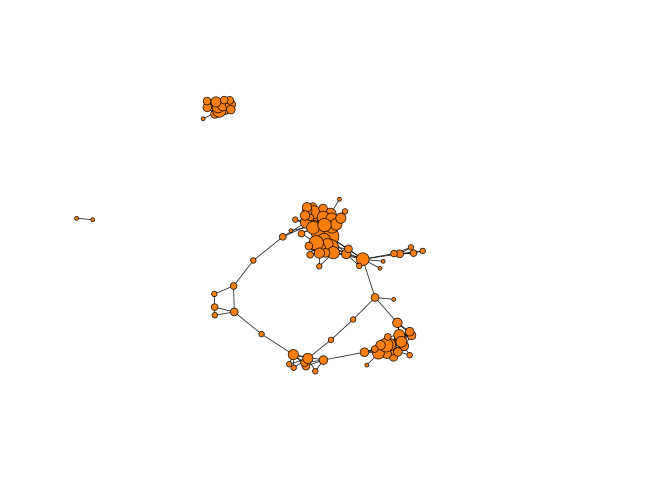

In [47]:
sizes = np.array(list(nx.degree_centrality(g).values()))
sizes = sizes / max(sizes) * 200
pos = nx.layout.spring_layout(g)
nx.draw(
    g,
    pos=pos,
    with_labels=False,
    node_size=sizes,
    width=0.5,
    linewidths=0.5,
    edgecolors='black',
    node_color='tab:orange')


In [62]:
# top nodes by Degree, Betweenness, Closeness, Eigenvector centrality
top_degree = sorted(nx.degree_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]
top_betweenness = sorted(nx.betweenness_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]
top_closeness = sorted(nx.closeness_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]
top_eigenvector = sorted(nx.eigenvector_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]

In [63]:
print(f"Top node by degree centrality: {top_degree}")
print(f"Top node by betweenness centrality: {top_betweenness}")
print(f"Top node by closeness centrality: {top_closeness}")
print(f"Top node by eigenvector centrality: {top_eigenvector}")

Top node by degree centrality: [('329115238', 0.21311475409836067), ('788473', 0.19672131147540983), ('20848418', 0.19672131147540983), ('153552036', 0.19672131147540983), ('87345513', 0.18032786885245902)]
Top node by betweenness centrality: [('171705539', 0.3004171421765347), ('75470808', 0.24814180684702666), ('329115238', 0.2105351340979137), ('247932292', 0.16382541314166138), ('20848418', 0.08467451505124444)]
Top node by closeness centrality: [('329115238', 0.2604861503674392), ('171705539', 0.25694212111073933), ('164398839', 0.24289705339729062), ('20848418', 0.23533016699862108), ('75470808', 0.2345993279706751)]
Top node by eigenvector centrality: [('153552036', 0.312985693343044), ('20848418', 0.30094761078865134), ('87345513', 0.2961323286535498), ('788473', 0.27867501238570574), ('329115238', 0.264110133943853)]


## Community detection